In [143]:
import pandas as pd #for manipulation
import numpy as np # for data generation
import matplotlib.pyplot as plt
import seaborn as sns #for visualization


In [144]:
#random data generation(statistical distributions)
#log-normal distribution to mimic real wealth distribution
np.random.seed(42) #setting seed for reproducibility :ensures that the names and numbers stay the same every time you run the cod
n_rows = 60
data= {'Customer_ID':np.random.randint(1000,1040,n_rows),'Age':np.random.normal(40,12,n_rows).astype(int),'Balance':np.random.lognormal(mean=8.5,sigma=0.8,size=n_rows),'Account_Type':np.random.choice(['Savings','Checking','Investment'],n_rows),'Region':np.random.choice(['North','South','East','West'],n_rows)}
df=pd.DataFrame(data)

print(df)

    Customer_ID  Age       Balance Account_Type Region
0          1038   48   3781.590069      Savings   West
1          1028   37   2466.909808      Savings   East
2          1014   29   3997.610798     Checking   West
3          1007   54   7106.495417      Savings  North
4          1020   49   1669.848231     Checking  North
5          1038   71   2174.908278      Savings   West
6          1018   43   5440.410472      Savings  North
7          1022   59   1808.847212   Investment   West
8          1010   45  23297.293910   Investment   East
9          1010   41   4347.389522      Savings   West
10         1023   21   2378.939834      Savings   East
11         1035   48   2555.790060   Investment   West
12         1039   29   3339.251159   Investment  North
13         1023   33   3115.476289   Investment   West
14         1002   39    922.161402     Checking  North
15         1021   36  13507.392736      Savings   West
16         1001   21   4854.266694   Investment   West
17        

In [145]:
#showing only the first 15 rows for argument's sake
print(df.head(15))

    Customer_ID  Age       Balance Account_Type Region
0          1038   48   3781.590069      Savings   West
1          1028   37   2466.909808      Savings   East
2          1014   29   3997.610798     Checking   West
3          1007   54   7106.495417      Savings  North
4          1020   49   1669.848231     Checking  North
5          1038   71   2174.908278      Savings   West
6          1018   43   5440.410472      Savings  North
7          1022   59   1808.847212   Investment   West
8          1010   45  23297.293910   Investment   East
9          1010   41   4347.389522      Savings   West
10         1023   21   2378.939834      Savings   East
11         1035   48   2555.790060   Investment   West
12         1039   29   3339.251159   Investment  North
13         1023   33   3115.476289   Investment   West
14         1002   39    922.161402     Checking  North


In [146]:
#manually injecting intentional flaws,in this case missing values in the 'Balance' and the 'Account_Type' columns
np.random.seed(42)
df.loc[df.sample(frac=0.1).index,'Age']=np.nan
df.loc[df.sample(frac=0.1).index,'Balance']=np.nan

print(df.head(15))

    Customer_ID   Age       Balance Account_Type Region
0          1038   NaN   3781.590069      Savings   West
1          1028  37.0   2466.909808      Savings   East
2          1014  29.0   3997.610798     Checking   West
3          1007  54.0   7106.495417      Savings  North
4          1020  49.0           NaN     Checking  North
5          1038   NaN   2174.908278      Savings   West
6          1018  43.0   5440.410472      Savings  North
7          1022  59.0   1808.847212   Investment   West
8          1010  45.0  23297.293910   Investment   East
9          1010  41.0   4347.389522      Savings   West
10         1023  21.0   2378.939834      Savings   East
11         1035  48.0   2555.790060   Investment   West
12         1039  29.0   3339.251159   Investment  North
13         1023   NaN   3115.476289   Investment   West
14         1002  39.0    922.161402     Checking  North


In [147]:
print(f"Dataset generated with {df.shape[0]} rows and simulated missing values in the Age and Balancecolumns")

Dataset generated with 60 rows and simulated missing values in the Age and Balancecolumns


In [148]:
#data cleaning :imputation(mathematical central tendecy)
df['Age']=df['Age'].fillna(df['Age'].median())
df['Balance']=df['Balance'].fillna(df['Balance'].mean())


In [149]:
#mathemattical feature engineering (z-scores and normalization)
#formula for Z-score :z = (x-mean)/sigma
df['Balance_ZScore']=(df['Balance']-df['Balance'].mean())/df['Balance'].std()


In [150]:
#min-max scaling (normalizing data to a 0-1 range)
#formula:x_scaled=(x-x_min)/(x_max-x_min)
b_min,b_max=df['Balance'].min(),df['Balance'].max()
df['Balance_Normalized']=(df['Balance']-b_min)/(b_max-b_min)

In [151]:
#Subsetting with loc and iloc
#identifying outliers : values with a Z_score > 2 (statistical significance)
outliers= df.loc[df['Balance_ZScore'].abs()>2 ]
subset_view = df.iloc[0:5,[0,2,5,6]] #positional slice of original + math metrics
                      

In [152]:
#Grouping and aggregation 
#statistical summary per region 
Regional_Stats=df.groupby('Region')['Balance'].agg(['mean','std','var']).reset_index()

In [153]:
#dictionary operations
#mapping regional varience to a dictionary for lookup simulation 
variance_map = Regional_Stats.set_index('Region')['var'].to_dict()
#converting dictionary back to a DataFrame to show data structure flexibility 
variance_df=pd.DataFrame(list(variance_map.items()),columns=['Region','Variance'])

Text(0.5, 1.0, 'Log-Normal Distribution of Balances')

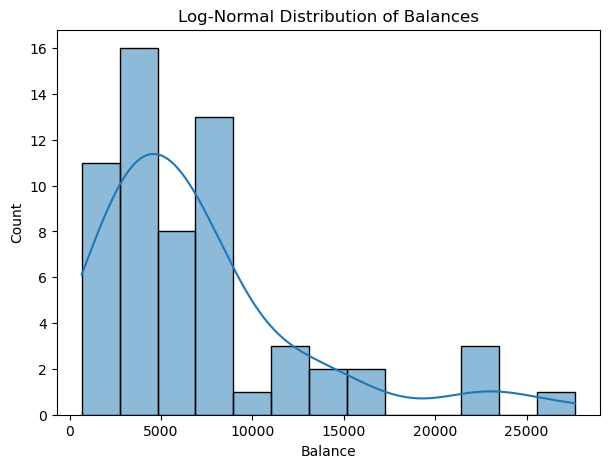

In [154]:
#visualization (distribution and correlation )
#subplot 1: Distribution showing the math of the data plt.subplot(1,2,1)
plt.figure(figsize=(7,5))
sns.histplot(df['Balance'],kde=True)
plt.title('Log-Normal Distribution of Balances')

<function matplotlib.pyplot.show(close=None, block=None)>

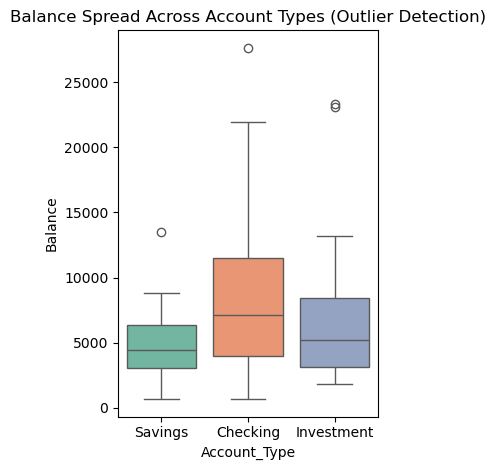

In [155]:
#industry standard Box Plot for Account Type portfolio
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Account_Type', y='Balance',hue='Account_Type', palette='Set2',legend=False)
plt.title('Balance Spread Across Account Types (Outlier Detection)')
plt.xlabel('Account_Type')
plt.ylabel('Balance')
plt.tight_layout()
plt.show